<a href="https://colab.research.google.com/github/sarina2668/sarina2668-Sarina_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [2]:
# write your answer here
import pandas as pd
import matplotlib.pyplot as plt
import mlxtend
import networkx as nx


from google.colab import files
uploaded = files.upload()

df= pd.read_csv('bread_basket.csv')

Saving bread_basket.csv to bread_basket (2).csv


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [3]:
# write your answer here
print(df.dtypes)
df.head(20)



transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend
5,3,Cookies,30/10/2016,10:07,morning,weekend
6,4,Muffin,30/10/2016,10:08,morning,weekend
7,5,Coffee,30/10/2016,10:13,morning,weekend
8,5,Pastry,30/10/2016,10:13,morning,weekend
9,5,Bread,30/10/2016,10:13,morning,weekend


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [4]:
# write your answer here

df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

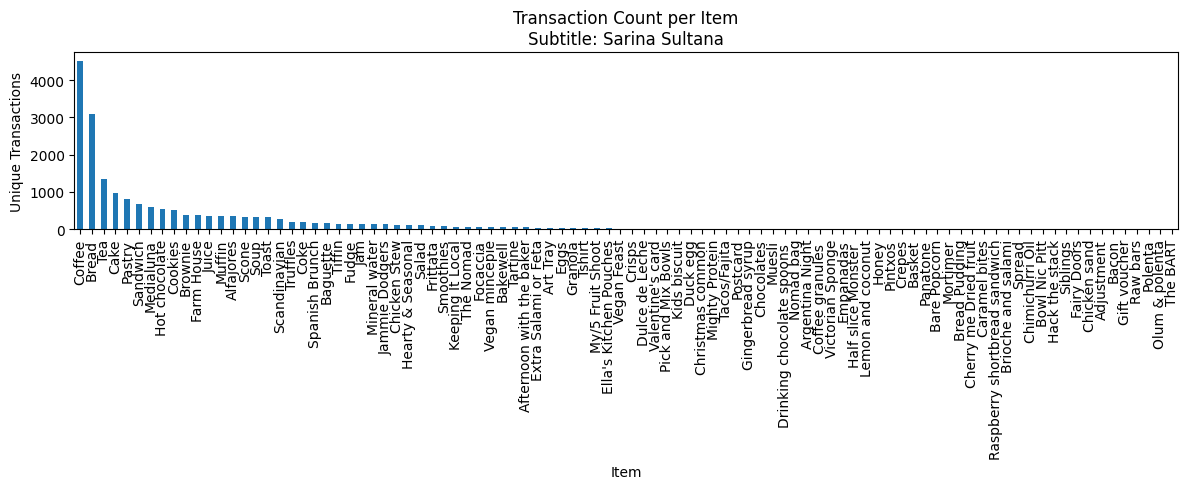

In [7]:
# c) Bar plot of transaction counts per item
subtitle = "Sarina Sultana"  # <-- EDIT THIS
item_counts =  df.groupby('item')['transaction'].nunique().sort_values(ascending=False)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [15]:
# write your answer here

print("Coffee:", (df['item'] == 'Coffee').sum())
print("Tea:", (df['item'] == 'Tea').sum())
print("Alfajores:", (df['item'] == 'Alfajores').sum())
print("Juice:", (df['item'] == 'Juice').sum())
print("Chicken Stew:", (df['item'] == 'Chicken Stew').sum())


Coffee: 5471
Tea: 1435
Alfajores: 369
Juice: 369
Chicken Stew: 123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [26]:
# write your answer here
from mlxtend.frequent_patterns import fpgrowth


pivot_df = pd.crosstab(df['transaction'], df['item']).astype(bool)


#pivot_df = pivot_df.astype(bool)

frequent_items = fpgrowth(pivot_df,
                             min_support=0.2,
                             use_colnames=True)

print(frequent_items)

    support  itemsets
0  0.327205   (Bread)
1  0.478394  (Coffee)


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [40]:
# write your answer here
from mlxtend.frequent_patterns import association_rules


rules=association_rules(frequent_items, metric="confidence", min_threshold=0.7)
print(rules)


Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

This rules means that customers who purchase coffee and cake are mostly likely to purchase bread in the same transaction.

Support: This represents the fraction of common transactions that contain bread, coffee, and cake together. For example, if the support value is 0.08, this means that 8% of transactions contain coffee, cake, and bread together.

Confidence: This means how frequent bread is in transaction with coffee and cake.

Lift>1: This compares how frequent bread appears with coffee and cake vs how frequent is appears with all the items. Lift>1 indicates that customers who buy coffee and cake are more likely to buy bread.

>